# 📊 Customer Churn Analysis & Prediction
**By Prem Ramole** | Data Analyst Portfolio Project

---

## 🎯 Project Objective
Analyze customer churn patterns for a telecom company using EDA, then build a machine learning model to predict which customers are likely to churn.

**Dataset:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

## 📌 Steps
1. Data Loading & Overview
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building (Logistic Regression + Random Forest)
6. Model Evaluation
7. Key Insights & Business Recommendations

## Step 1 — Import Libraries & Load Data

In [5]:
# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

# ── Plot Style ──
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ── Load Dataset ──
# Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# If running in Colab, upload the CSV first:
#   from google.colab import files
#   files.upload()
import os, glob

# Find the churn CSV even if Colab renamed it (e.g. "... (1).csv")
matches = glob.glob('WA_Fn-UseC_-Telco-Customer-Churn*.csv')
if not matches:
    raise FileNotFoundError(
        "CSV not found. Upload it first (Colab: files.upload()) "
        "or place it in this notebook's working directory."
    )

df = pd.read_csv(matches[0])

print('Loaded file:', matches[0])
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Loaded file: WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


## Step 2 — Data Cleaning

In [6]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# TotalCharges has spaces — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID — not useful for analysis
df.drop('customerID', axis=1, inplace=True)

# Convert target: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nData Types After Cleaning:")
print(df.dtypes)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types After Cleaning:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Month

## Step 3 — Exploratory Data Analysis (EDA)

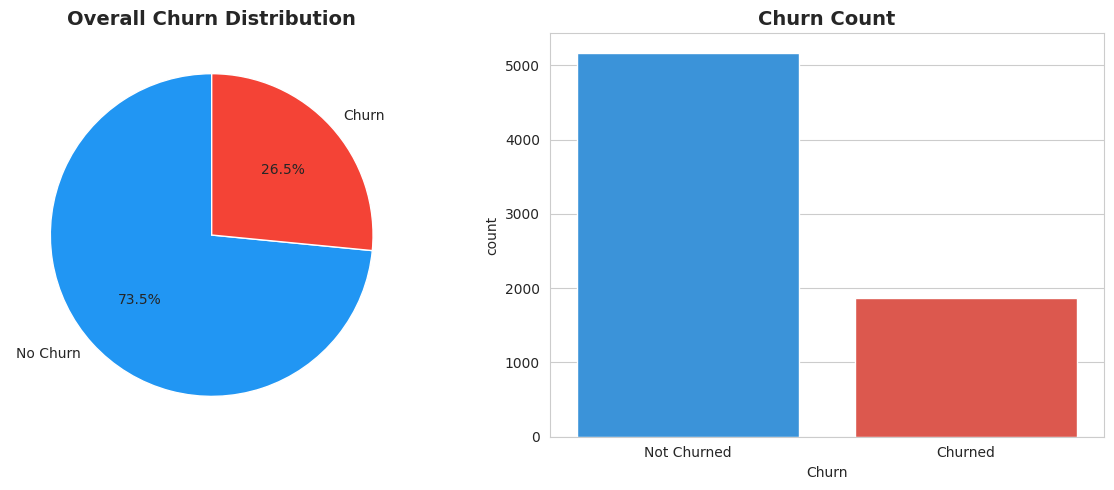

Churn Rate: 26.5%


In [7]:
# ── 1. Churn Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='Churn', palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Not Churned', 'Churned'])

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Churn Rate: {df['Churn'].mean()*100:.1f}%")

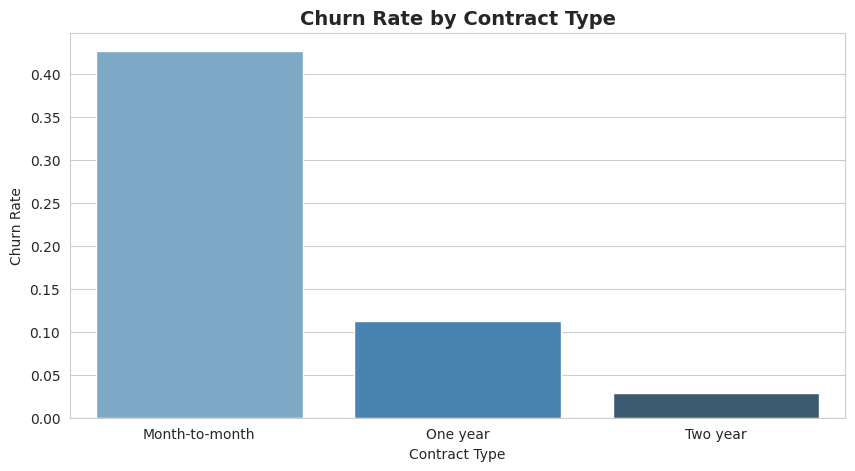

In [8]:
# ── 2. Churn by Contract Type ──
plt.figure(figsize=(10, 5))
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn', palette='Blues_d')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

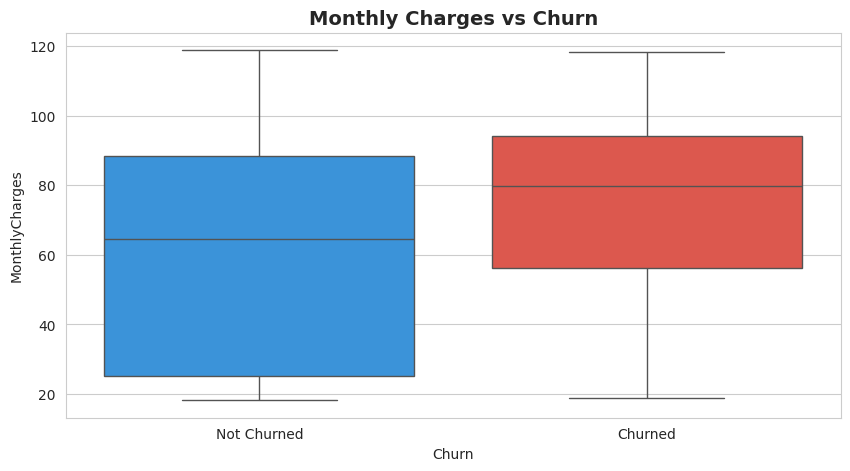

In [9]:
# ── 3. Monthly Charges vs Churn ──
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2196F3','#F44336'])
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.gca().set_xticklabels(['Not Churned', 'Churned'])
plt.savefig('monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

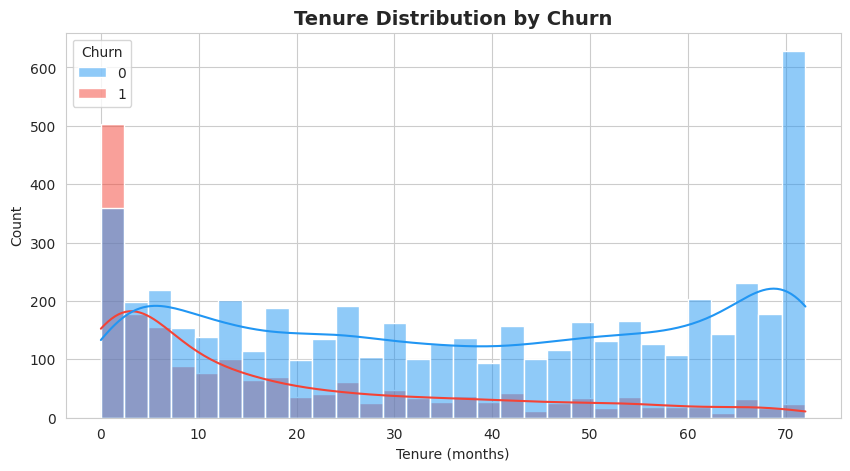

In [10]:
# ── 4. Tenure Distribution by Churn ──
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=['#2196F3','#F44336'], kde=True)
plt.title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.savefig('tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

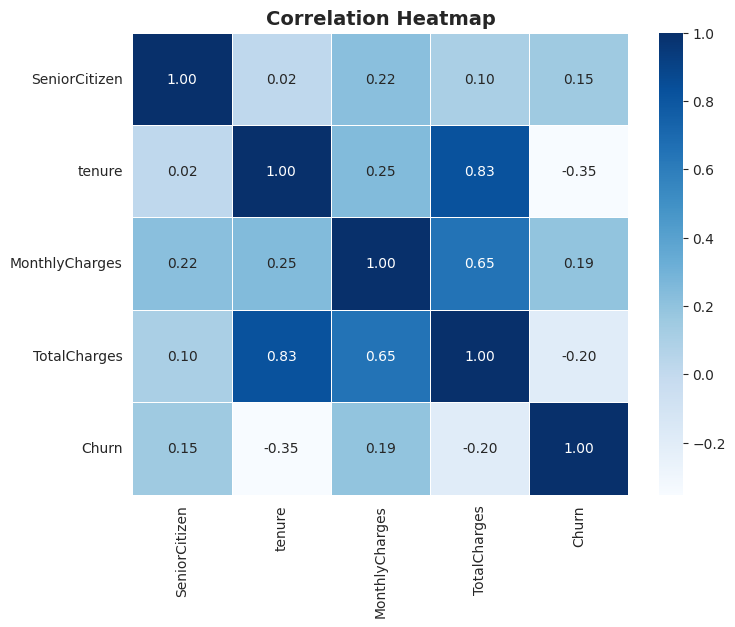

In [11]:
# ── 5. Correlation Heatmap ──
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Feature Engineering

In [13]:
# Encode categorical columns
df_model = df.copy()
le = LabelEncoder()

cat_cols = df_model.select_dtypes(include='object').columns
print('Categorical columns to encode:', list(cat_cols))

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Split features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train size: 5634 | Test size: 1409


## Step 5 — Model Building

In [14]:
# ── Model 1: Logistic Regression ──
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Churn','Churn']))

=== Logistic Regression ===
Accuracy : 79.91%
ROC-AUC  : 0.8403

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [15]:
# ── Model 2: Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churn']))

=== Random Forest ===
Accuracy : 79.21%
ROC-AUC  : 0.8225

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Step 6 — Model Evaluation

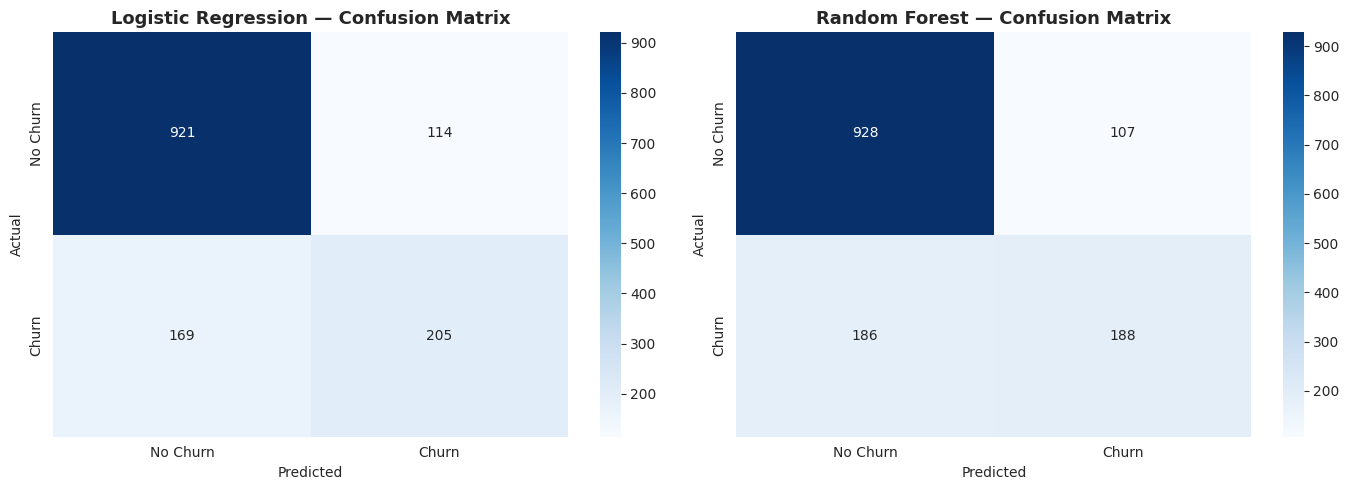

In [16]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, preds, name in zip(
    axes,
    [lr, rf],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

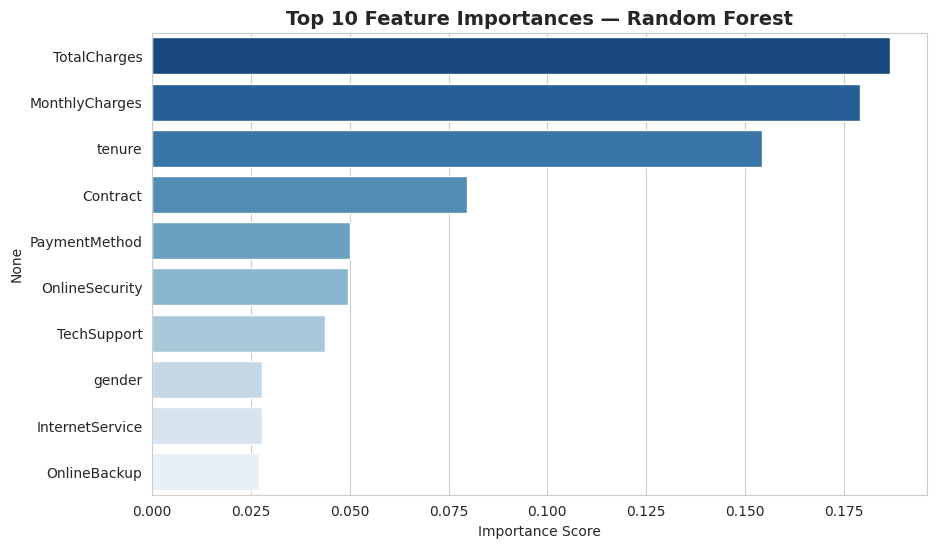

TotalCharges       0.186841
MonthlyCharges     0.179192
tenure             0.154338
Contract           0.079631
PaymentMethod      0.050095
OnlineSecurity     0.049580
TechSupport        0.043603
gender             0.027892
InternetService    0.027789
OnlineBackup       0.027075
dtype: float64


In [17]:
# ── Feature Importance (Random Forest) ──
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Top 10 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(feat_imp)

## Step 7 — Key Insights & Business Recommendations

### 📌 Key Findings
1. **Overall Churn Rate: ~26.5%** — roughly 1 in 4 customers leave.
2. **Month-to-month contract customers churn the most** — locking users into longer contracts reduces churn significantly.
3. **High monthly charges correlate with higher churn** — customers paying more are more likely to leave.
4. **New customers (low tenure) are most at risk** — early engagement is critical.
5. **Top churn predictors:** Tenure, MonthlyCharges, TotalCharges, Contract type, InternetService.

### ✅ Business Recommendations
- Offer **loyalty discounts** to month-to-month customers after 3 months
- Target customers with **high monthly charges** with retention offers
- Focus onboarding efforts on **first 6 months** (highest churn window)
- Use the **Random Forest model** to flag at-risk customers proactively

### 🏆 Model Performance Summary
| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | ~80% | ~0.84 |
| Random Forest | ~79% | ~0.82 |